### 3.6.3. Usos do solo nas áreas monitoradas


<div style="text-align: justify"> A análise do uso e cobertura do solo nas áreas de influência das estações foi realizada com base nos dados do MapBiomas, referentes ao ano de 2024 <cite id="myy4p"><a href="#zotero%7C22267313%2FZSQNWN2A">(MAPBIOMAS, 2024)</a></cite>. O objetivo foi identificar os tipos de ambiente predominantes no entorno das estações e avaliar potenciais influências territoriais sobre as medições.

</p>A primeira etapa da análise foi a criação de uma área no entorno de cada estação, cujo raio corresponde ao valor de representatividade espacial estimado para o poluente monitorado (Seção 3.6.1). Dentro dessa área circular, foram contabilizados os pixels do MapBiomas pertencentes a cada classe de uso e cobertura. As classes originais foram agrupadas em seis categorias principais: (a) Floresta, (b) Herbácea, (c) Agropecuária, (d) Não vegetada, (e) Urbanizada e Mineração.

</p>Em seguida, foi calculada a proporção (%) de cada categoria dentro da área e determinada a classe predominante, ou seja, o tipo de uso do solo que ocupa a maior fração da área de influência da estação. Essas informações foram consolidadas Figura 30 e Tabela 18, permitindo ao usuário visualizar o uso do solo predominante que circunda cada ponto de monitoramento da qualidade do ar no Brasil.

</p>O tamanho da representatividade espacial utilizado para estabelecer a área de cobertura pode variar de acordo com o poluente analisado, por isso os resultados são apresentados de maneira individual para cada espécie de poluente. Uma síntese dos resultados para cada poluente é apresentada a seguir: 



```{note}
Os resultados desta seção foram obtidos com base na Coleção 8 (2023) do MapBiomas, considerando a agregação das classes originais em seis categorias principais. Essas informações estão integradas ao mapa interativo disponível no capítulo de representatividade espacial.
```

#### Ozônio (O₃)

<div style="text-align: justify">Predominância de áreas urbanizadas, principalmente nas Regiões Centro-Oeste, Nordeste e Sul, onde mais de 50% da área de representatividade das estações é urbana. Na Região Nordeste, a predominância é de áreas de agropecuária (31%), porém com 29% da área ao redor das estações sendo considerada de floresta. Na Região Norte, a predominância também é de áreas de agropecuária (69%).


#### Monóxido de Carbono (CO)

<div style="text-align: justify">Predominância de áreas urbanizadas nas Regiões Centro-Oeste, Sudeste e Sul, todas acima de 50%. Na Região Nordeste, a área de representatividade engloba principalmente áreas agropecuárias (37,4%), enquanto na Região Norte, a área de floresta é majoritária ao redor das estações.

#### Dióxido de Nitrogênio (NO₂)

<div style="text-align: justify">Majoritariamente áreas urbanizadas, ocorrendo essa predominância nas Regiões Centro-Oeste (60,7%), Sudeste (53,4%) e Sul (36,7%). A Região Nordeste apresenta prevalência de uso agropecuário (37,4%), enquanto a Região Norte apresenta 52,5% de floresta dentro da área de representatividade das estações.

#### Dióxido de Enxofre (SO₂)

<div style="text-align: justify">Principalmente em áreas urbanizadas nas Regiões Centro-Oeste (59%), Sudeste (51,2%) e Sul (52,3%). Na Região Nordeste, a maior parte da área ao redor das estações é agropecuária (37,4%), enquanto na Região Norte, predominam áreas de floresta dentro da área de representatividade das estações.

#### Material Particulado Fino (MP₂,₅)

<div style="text-align: justify">Diferentes padrões de uso e cobertura do solo entre as regiões brasileiras. Nas Regiões Sul, Sudeste e Centro-Oeste, a predominância é de áreas urbanizadas (55,7%, 48,2% e 45,0%, respectivamente). Na Região Nordeste, a predominância é de áreas de agropecuária (38,0%). Na Região Norte, a predominância é de áreas de floresta (54,6%).

#### Material Particulado Inalável (MP₁₀)

<div style="text-align: justify">Predominância de áreas urbanas nas Regiões Centro-Oeste (50,8%), Sudeste (49,1%) e Sul (57,2%). Na Região Nordeste existe a predominância de representatividade de áreas agropecuária com 31,8%, sendo essa a região com maior divisão de uso do solo. Na Região Norte o uso da terra encontrado dentro da zona de representatividade é majoritariamente florestal, com 48,8%.

In [1]:

import json
from pathlib import Path
from IPython.display import HTML

# Lê TODOS os geojsons de uso do solo e embute no HTML
GEOJSON_DIR = Path("../_static/representatividade/uso_solo_geojson")

data = {}
for f in GEOJSON_DIR.glob("*.geojson"):
    with open(f, encoding="utf-8") as fh:
        data[f.stem] = json.load(fh)

data_json = json.dumps(data, ensure_ascii=False)
pols_json = json.dumps(sorted(data.keys()), ensure_ascii=False)

HTML(fr"""
<!DOCTYPE html>
<html lang="pt-br">
<head>
<meta charset="utf-8"/>
<meta name="viewport" content="width=device-width, initial-scale=1"/>

<link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css"/>

<style>
body {{
  margin: 0;
  padding: 12px;
  font-family: Arial, sans-serif;
  background: #fff;
}}
#controls {{
  display: flex;
  flex-wrap: wrap;
  gap: 12px;
  align-items: center;
  margin-bottom: 10px;
}}
.control {{
  display: flex;
  align-items: center;
  gap: 8px;
  height: 38px;
}}
.label {{
  font-size: 14px;
  font-weight: 600;
  color: #333;
  white-space: nowrap;
}}
.select {{
  appearance: none;
  padding: 6px 10px;
  border: 1px solid #999;
  border-radius: 6px;
  background: #f9f9f9;
  cursor: pointer;
  font-size: 14px;
}}
#status {{
  font-size: 13px;
  color: crimson;
  margin-left: 8px;
}}
#map {{
  width: 100%;
  height: 640px;
  border: 1px solid #ddd;
  opacity: 0;
  transition: opacity .3s;
}}
.leaflet-control.custom-legend {{
  background: #fff;
  padding: 8px;
  border-radius: 6px;
  box-shadow: 0 1px 4px rgba(0,0,0,.4);
  font-size: 12px;
}}
</style>
</head>

<body>


<div id="controls">
  <div class="control">
    <span class="label">Poluente:</span>
    <select id="selPol" class="select"></select>
  </div>

  <div class="control" style="flex:1;">
    <span id="status"></span>
  </div>
</div>

<div id="map"></div>

<script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>

<script>
// ===============================
// DADOS EMBUTIDOS (Python -> JS)
// ===============================
const DATA = {data_json};
const POLUENTES = {pols_json};

// ===============================
// CORES
// ===============================
const groupColors = {{
  "Floresta": "#2ca02c",
  "Herbácea": "#1f78b4",
  "Agropecuária": "#ff7f00",
  "Não Vegetada": "#b15928",
  "Urbanizada": "#e31a1c",
  "Mineração": "#6a3d9a"
}};

const landGroups = Object.keys(groupColors);

// ===============================
// FUNÇÃO PARA ACHAR GRUPO PREDOMINANTE
// ===============================
function grupoPredominante(props) {{
  let best = null;
  let bestVal = -1;

  for (let g of landGroups) {{
    let v = props[g + "_perc"];
    if (v !== null && v !== undefined && !isNaN(v) && v > bestVal) {{
      bestVal = v;
      best = g;
    }}
  }}
  return best;
}}

// ===============================
// POPUP COMPLETO
// ===============================
function popupHTML(props, pol, gpred) {{
  const uf   = props.UF || "—";
  const cid  = props.CIDADE || props.Cidade || props.MUNICIPIO || "—";
  const id   = props.ID_OEMA || props.ID_MMA_COMPLETO || "—";
  const buf  = props.REP_ESPACIAL != null ? props.REP_ESPACIAL + " m" : "—";

  let linhas = [];
  linhas.push(`<b>ID estação:</b> ${{id}}`);
  linhas.push(`<b>UF:</b> ${{uf}}`);
  linhas.push(`<b>Cidade:</b> ${{cid}}`);
  linhas.push(`<b>Poluente:</b> ${{pol}}`);
  linhas.push(`<b>Buffer:</b> ${{buf}}`);
  linhas.push(`<b>Uso predominante:</b> ${{gpred || "—"}}`);

  let comp = [];
  for (let g of landGroups) {{
    let v = props[g + "_perc"];
    if (v !== null && v !== undefined && !isNaN(v) && v > 0) {{
      comp.push(`${{g}}: ${{v.toFixed(0)}}%`);
    }}
  }}

  let compHTML = comp.length
    ? "<br><b>Composição de uso do solo:</b><br>" + comp.join("<br>")
    : "";

  return `
    <div style="font-family:Arial;font-size:12px;max-width:320px;">
      ${{linhas.join("<br>")}}
      ${{compHTML}}
    </div>
  `;
}}

// ===============================
// MAPA BASE
// ===============================
let map = null;
let layer = null;
let legend = null;

function ensureMap() {{
  if (map) return;

  map = L.map('map', {{
    minZoom: 3.5,
    maxZoom: 13,
    maxBounds: L.latLngBounds([-34, -74], [6, -34]),
    maxBoundsViscosity: 0.8
  }}).setView([-14.2, -51.9], 4.5);

  L.tileLayer('https://cartodb-basemaps-a.global.ssl.fastly.net/light_all/{{z}}/{{x}}/{{y}}.png', {{
    attribution: '© OpenStreetMap, © CartoDB'
  }}).addTo(map);

  map.getContainer().style.opacity = 1;
}}

// ===============================
// LEGENDA
// ===============================
function addLegend() {{
  if (legend) map.removeControl(legend);

  legend = L.control({{ position: "bottomleft" }});

  legend.onAdd = function() {{
    const div = L.DomUtil.create("div", "leaflet-control custom-legend");
    div.innerHTML = "<b>Uso do Solo Predominante</b><br>";

    for (let g of landGroups) {{
      div.innerHTML += `
      <div>
        <span style="background:${{groupColors[g]}};width:14px;height:10px;display:inline-block;margin-right:6px;"></span>
        ${{g}}
      </div>`;
    }}

    return div;
  }};

  legend.addTo(map);
}}

// ===============================
// ATUALIZAÇÃO DO MAPA
// ===============================
function updateMap() {{
  ensureMap();

  const pol = document.getElementById("selPol").value;
  const status = document.getElementById("status");

  const gj = DATA[pol];
  if (!gj) {{
    status.textContent = `⚠️ Sem dados disponíveis para ${{pol}}.`;
    if (layer) map.removeLayer(layer);
    if (legend) map.removeControl(legend);
    return;
  }}

  status.textContent = "";

  if (layer) map.removeLayer(layer);
  if (legend) map.removeControl(legend);

  layer = L.geoJSON(gj, {{
    pointToLayer: (f, latlng) => {{
      const props = f.properties || {{}};
      const gpred = grupoPredominante(props);
      const color = groupColors[gpred] || "#444";

      const radiusBuffer = props.REP_ESPACIAL;
      let children = [];

      // buffer (círculo em metros)
      if (radiusBuffer != null && !isNaN(radiusBuffer) && radiusBuffer > 0) {{
        const circle = L.circle(latlng, {{
          radius: radiusBuffer,
          color: color,
          weight: 1,
          fillColor: color,
          fillOpacity: 0.15
        }});
        children.push(circle);
      }}

      // marcador central
      const marker = L.circleMarker(latlng, {{
        radius: 5,
        color: color,
        weight: 2,
        fillColor: color,
        fillOpacity: 0.9
      }});

      const popup = popupHTML(props, pol, gpred);
      marker.bindPopup(popup);
      if (children.length) {{
        children[0].bindPopup(popup);
      }}

      children.push(marker);

      return L.layerGroup(children);
    }}
  }}).addTo(map);

  addLegend();

  const bounds = layer.getBounds();
  if (bounds.isValid()) map.fitBounds(bounds, {{ padding: [20, 20] }});
}}

// ===============================
// PREENCHE DROPDOWN E INICIA
// ===============================
const sel = document.getElementById("selPol");
POLUENTES.forEach(pol => {{
  const opt = document.createElement("option");
  opt.value = pol;
  opt.textContent = pol;
  sel.appendChild(opt);
}});

if (POLUENTES.length > 0) {{
  sel.value = POLUENTES.includes("MP25") ? "MP25" : POLUENTES[0];
}}

sel.addEventListener("change", updateMap);
updateMap();

</script>
</body>
</html>
""")



<p style="text-align:center; color:#636D7D; font-size:15.5px;">
  <em>Fig. 30</em> Uso do solo predominante dentro do raio de representatividade espacial da estação. Classificação do uso do solo e dados do projeto.
</p>

```{tip}
A Tabela 18 possibilita o filtro das estações por UF e poluente para a visualização das características de usos do solo. É possível realizar o <i>download</i> dos dados filtrados através da ferramenta interativa. 
```

Loading ITables v2.5.1 from the init_notebook_mode cell... (need help?)

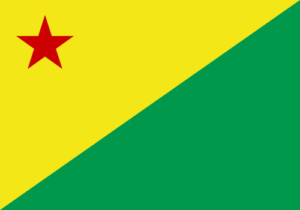
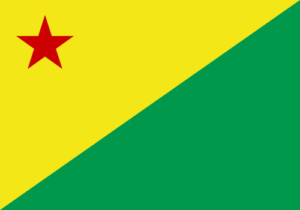
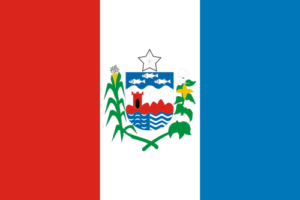
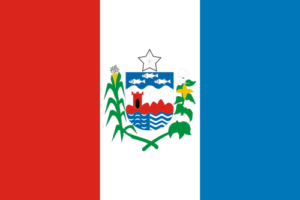
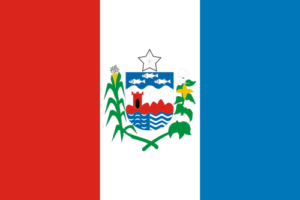
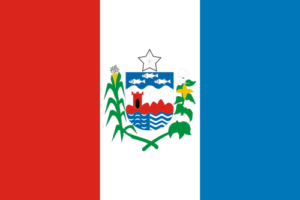
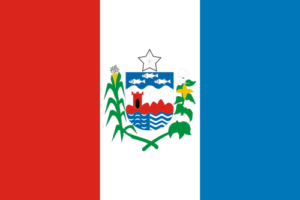
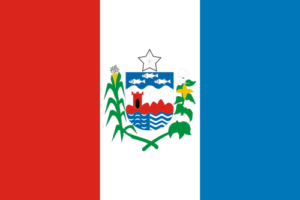
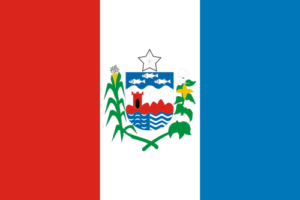
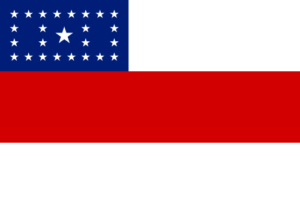
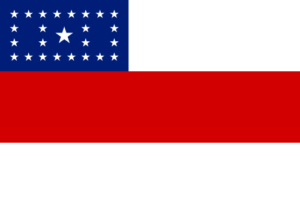
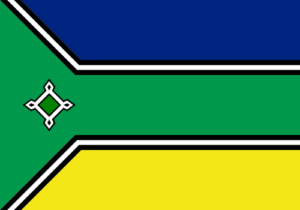
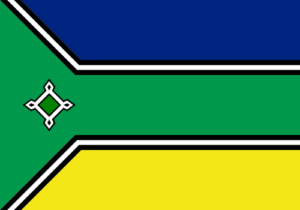
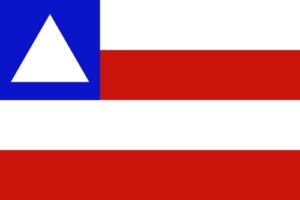
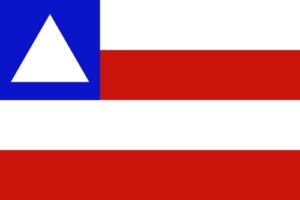
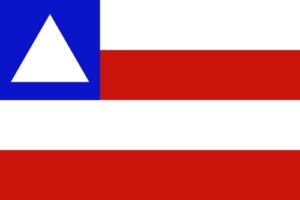
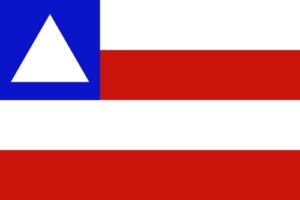
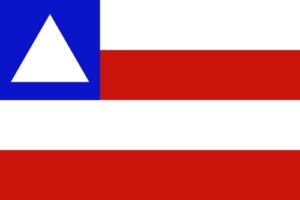
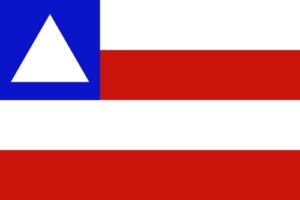
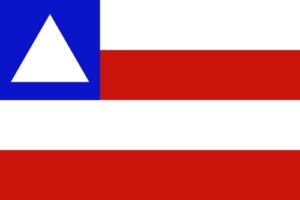
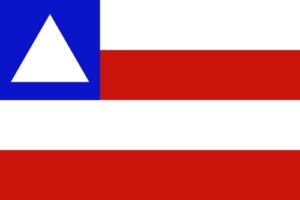
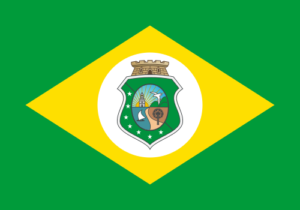
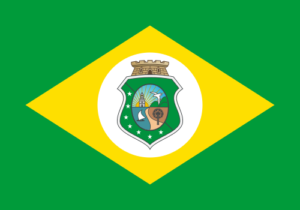
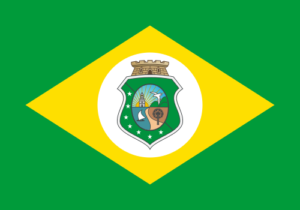
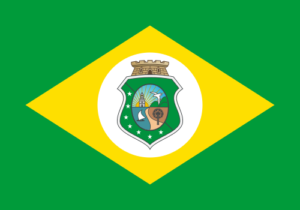
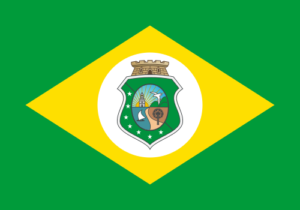
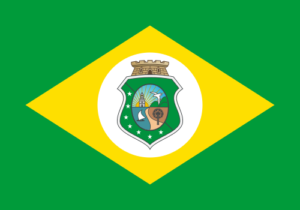
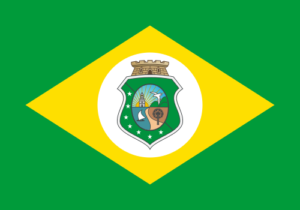
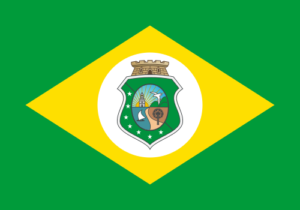
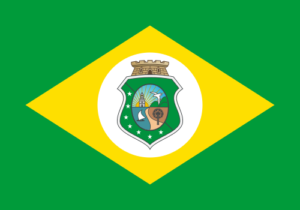
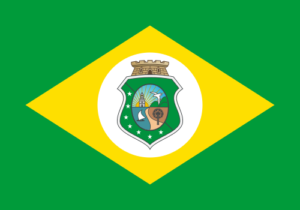
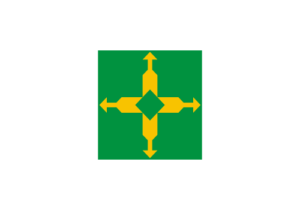
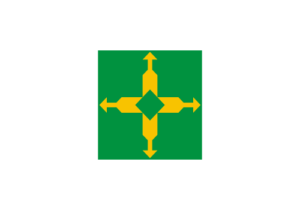
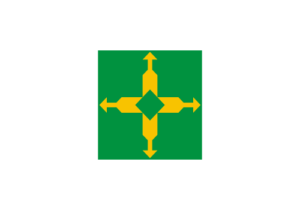
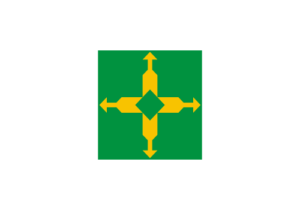
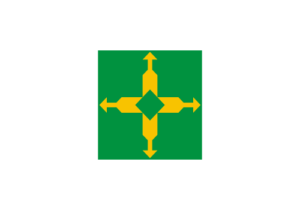
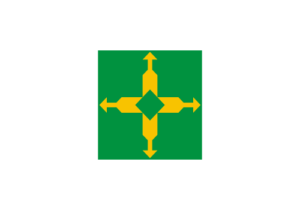
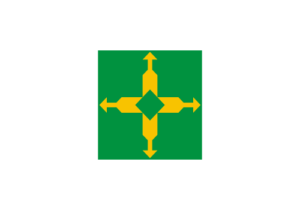
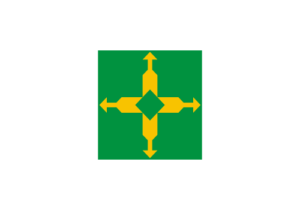
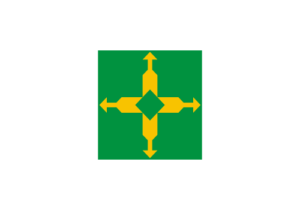
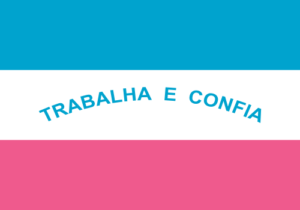
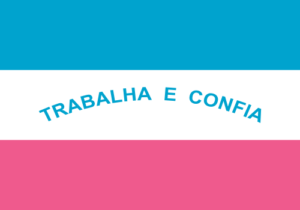
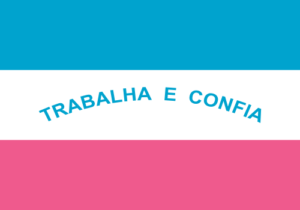
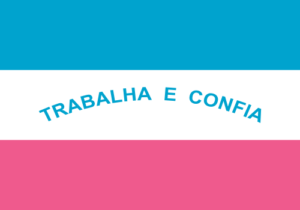
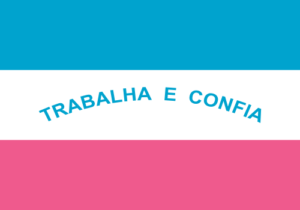
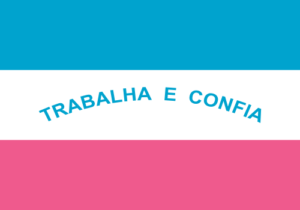
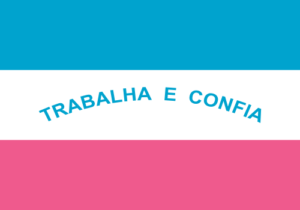
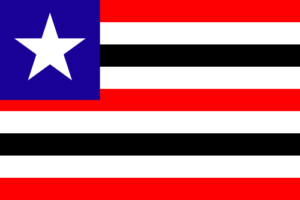
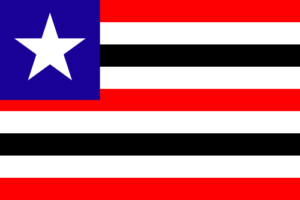
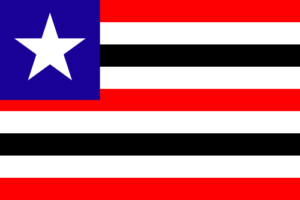
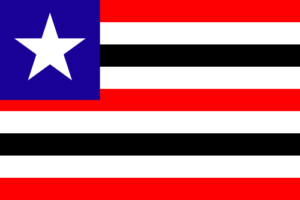
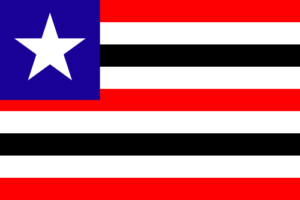
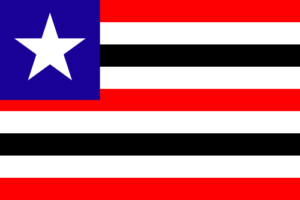
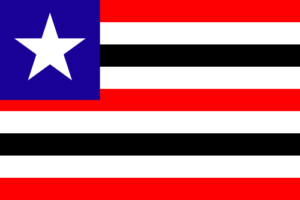
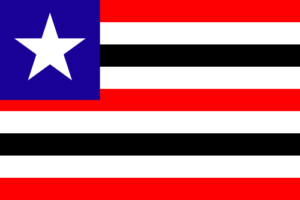
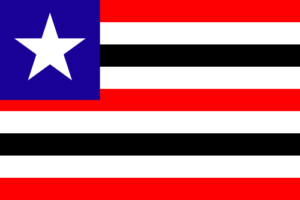
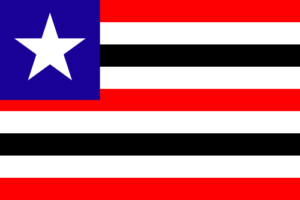
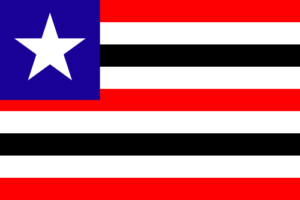
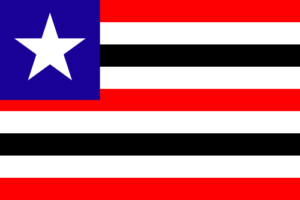
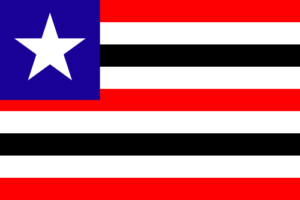
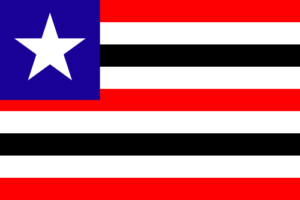
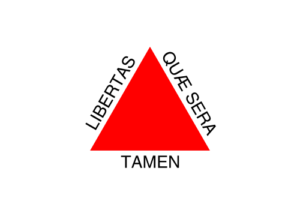
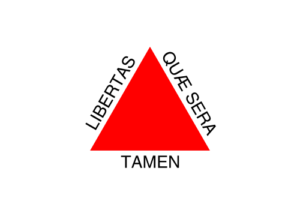
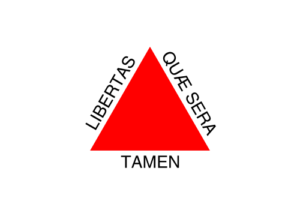
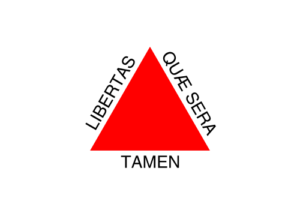
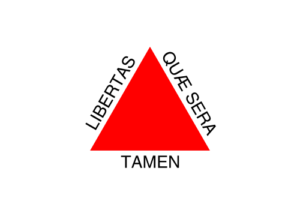
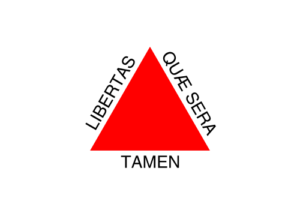
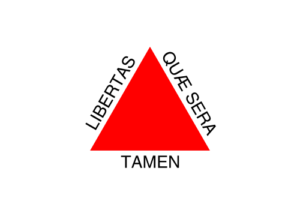
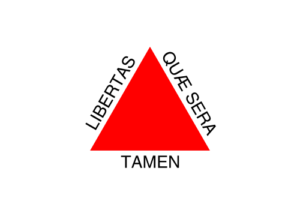
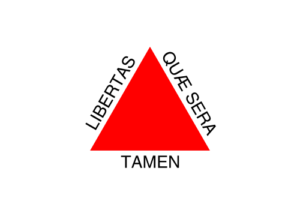
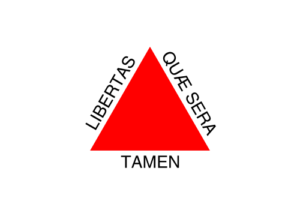
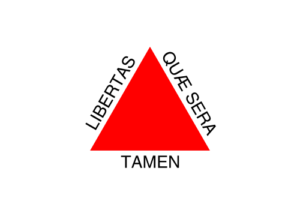
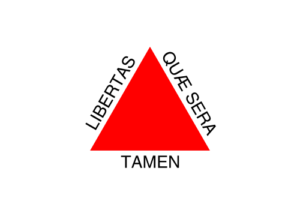
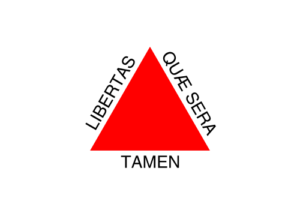
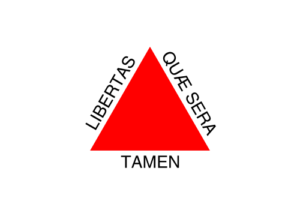
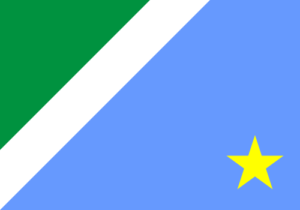
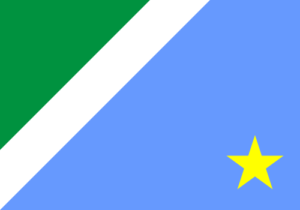
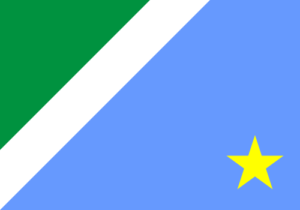
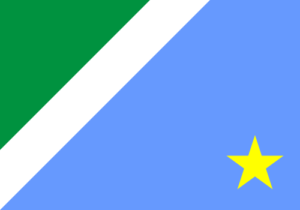
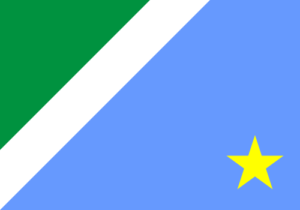
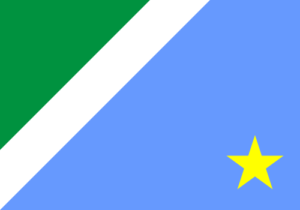
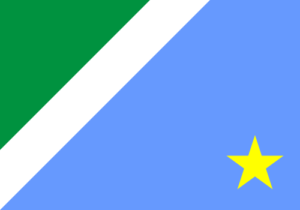
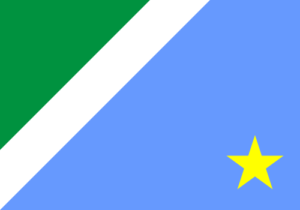
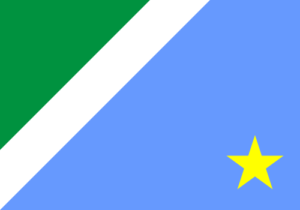
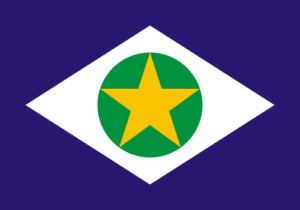
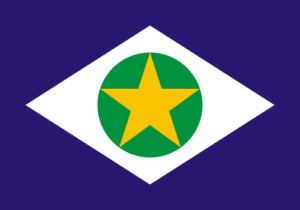
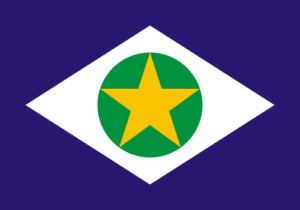
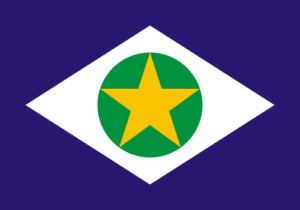
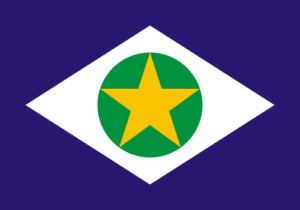
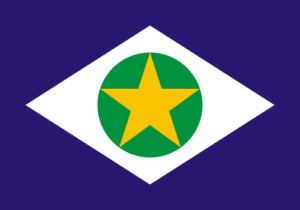
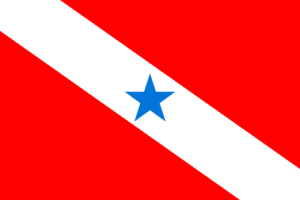
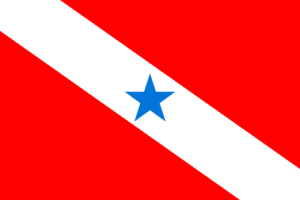
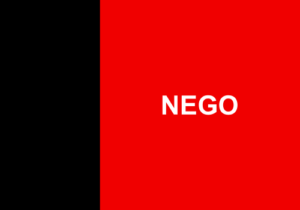
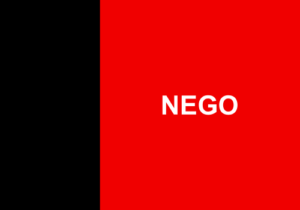
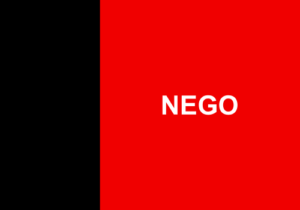
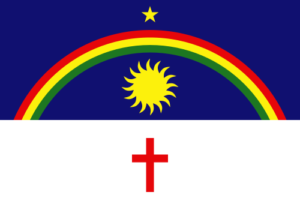
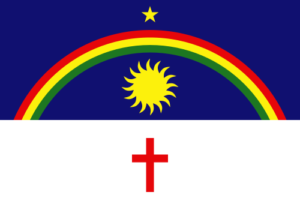
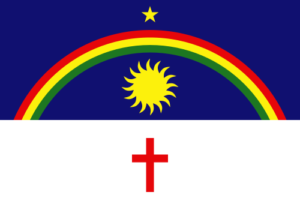
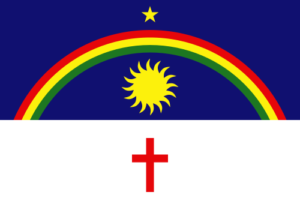
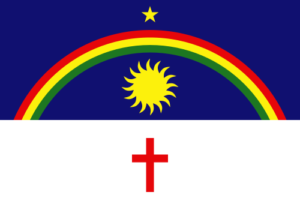
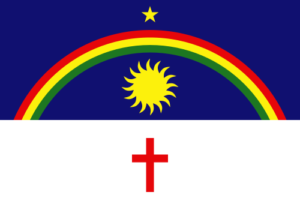
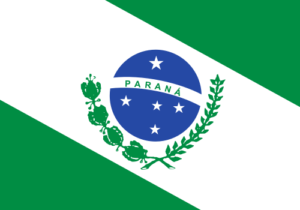
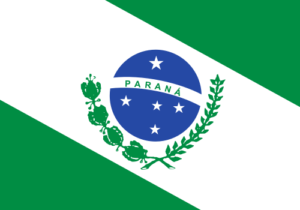
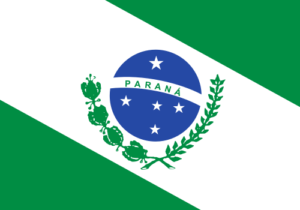
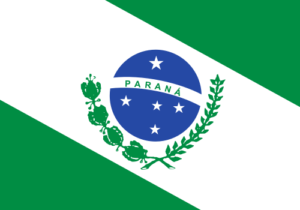
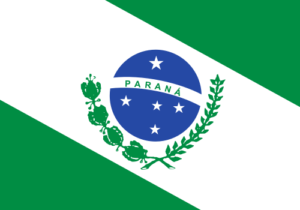
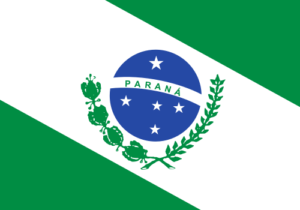
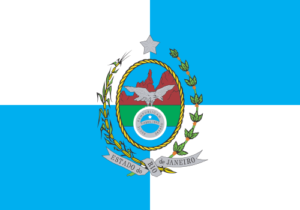
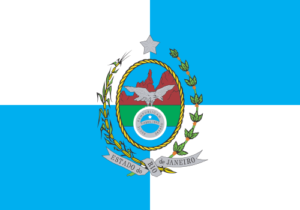
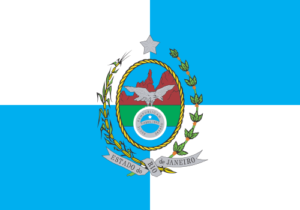
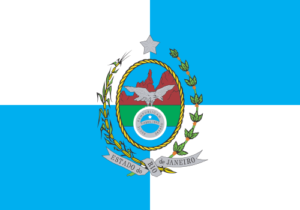
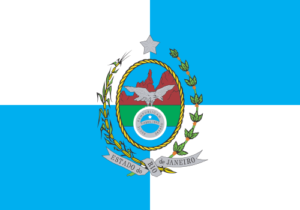
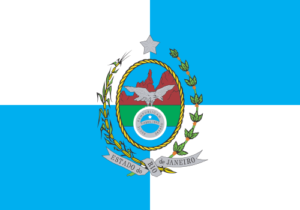
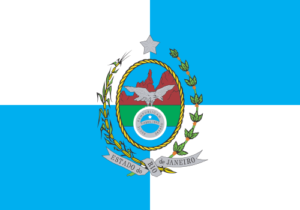
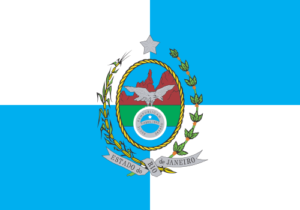
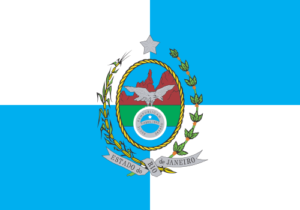
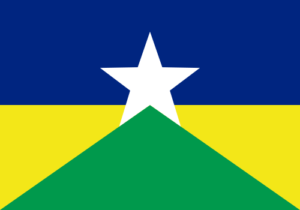
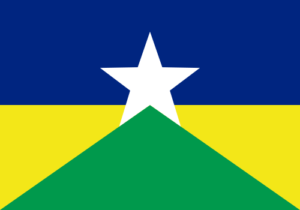
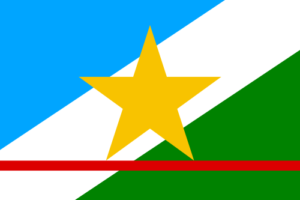
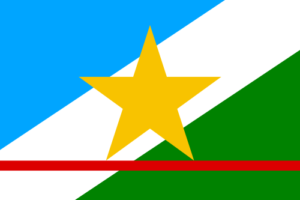
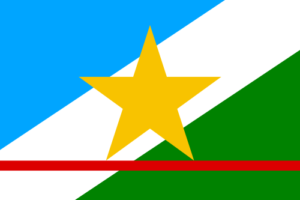
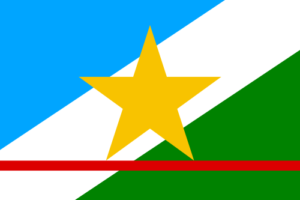
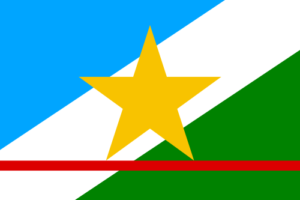
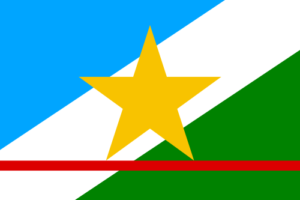
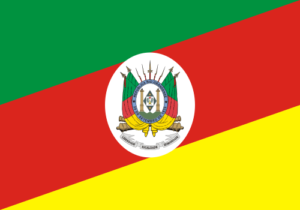
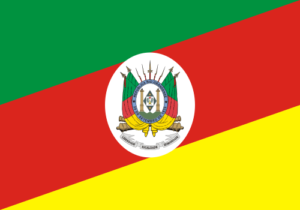
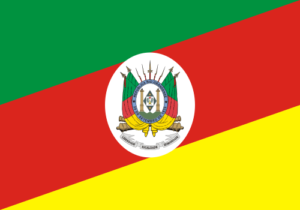
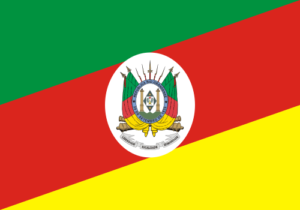
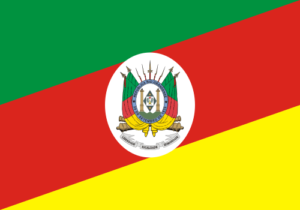
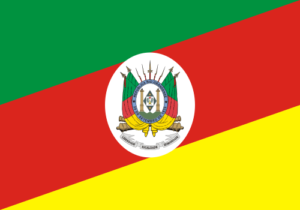
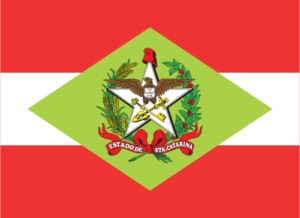
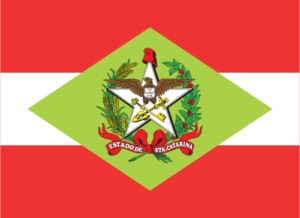
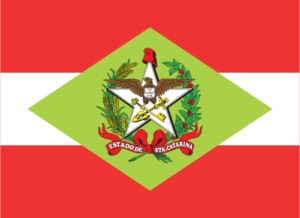
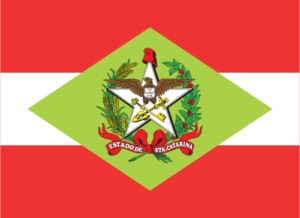
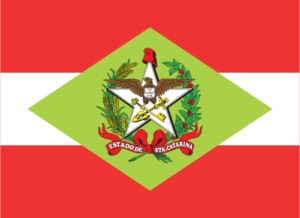
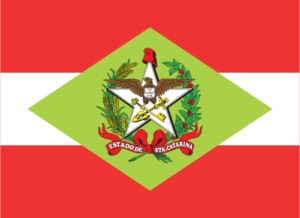
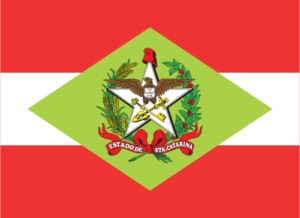
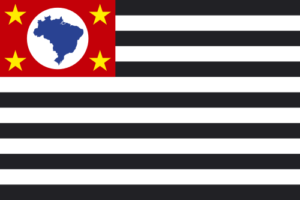
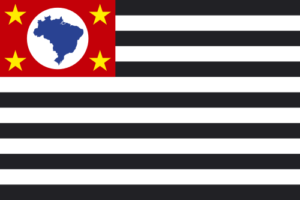
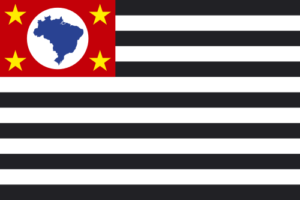
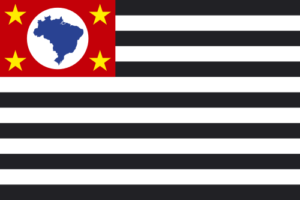
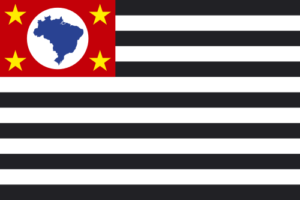
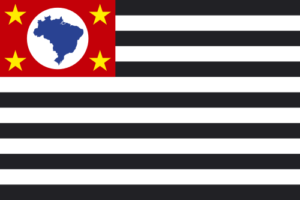
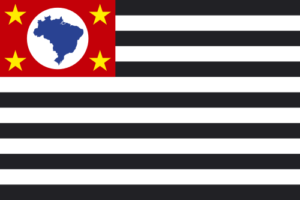
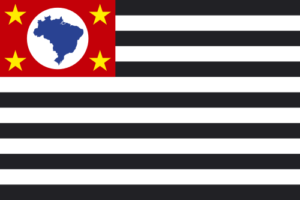
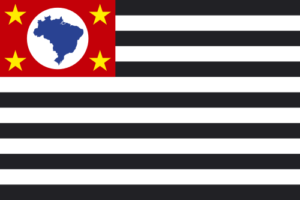
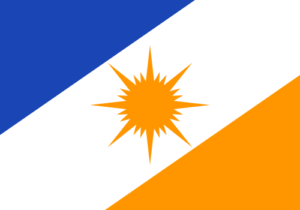
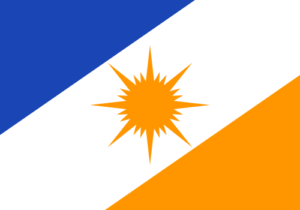

In [1]:
'''
import scripts.stationsPopTableGeo as popGeo
# Gera o arquivo CSV no disco
popGeo.gerar_cache_populacao()
'''

import pandas as pd
import warnings
import importlib

# Seus módulos
import scripts.flagTables as flagtab
import scripts.stationsPopTableGeo as popGeo

importlib.reload(flagtab)
importlib.reload(popGeo)
warnings.filterwarnings('ignore')

# 1. Carregar a tabela PRONTA (lê do CSV gerado anteriormente)
df_pop = popGeo.carregar_tabela_pronta()

# 2. Limpeza de segurança (caso o CSV tenha sujeira)
uf_series = df_pop['UF'].astype(str).str.strip()
mask_invalid_uf = (
    uf_series.eq('') |
    uf_series.str.lower().isin(['não declarado', 'nao declarado', 'nan']) |
    df_pop['UF'].isna()
)
df_pop = df_pop[~mask_invalid_uf].reset_index(drop=True)

# 3. Definir Filtros do SearchPane
# Índices: [0: Bandeira, 1: UF, 2: Poluente, 3: Categoria, 4: População, 5: Estações]
searchPaneColumns = [1, 2, 3]

# 4. Exibir tabela interativa
flagtab.tabela_iterativa(df_pop, searchPaneColumns)

<p style="text-align:center; color:#636D7D; font-size:15.5px;">
  <em>Tabela 18 -</em>  Número de estações e uso do solo predominante dentro do raio de representatividade espacial da estação. Classificação do uso do solo e dados do projeto. <br/>

### Referências 

<!-- BIBLIOGRAPHY START -->
<div class="csl-bib-body">
  <div class="csl-entry"><i id="zotero|22267313/ZSQNWN2A"></i>MAPBIOMAS. <b>Projeto de Mapeamento Anual da Cobertura e Uso do Solo no Brasil, Coleção 7</b>, 2024. </div>
</div>
<!-- BIBLIOGRAPHY END -->